In [202]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(sample)

print("Predicted Flower:", iris.target_names[prediction][0])

Accuracy: 1.0
Predicted Flower: setosa


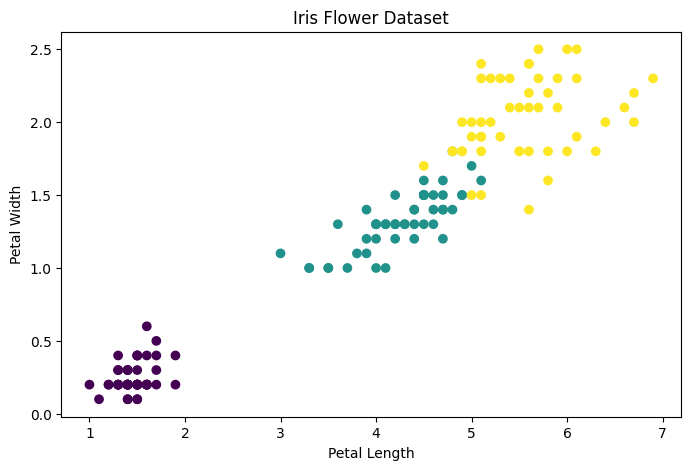

In [203]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    iris.data[:, 2],
    iris.data[:, 3],
    c=iris.target
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Flower Dataset")

plt.show()

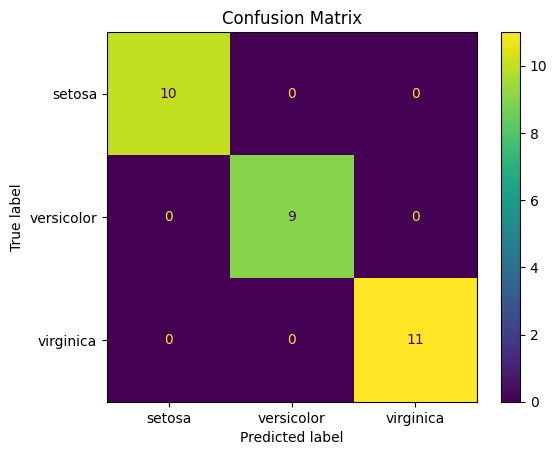

In [204]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [205]:
import pandas as pd

df = pd.read_csv("/content/IMDb Movies India.csv", encoding="latin1")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (15509, 10)


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [206]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


In [207]:
# Remove rows where Rating is missing
df = df.dropna(subset=['Rating'])

print("Shape after removing missing ratings:", df.shape)
print("Missing ratings:", df['Rating'].isnull().sum())

Shape after removing missing ratings: (7919, 10)
Missing ratings: 0


In [208]:
# Clean and convert Year
df['Year'] = df['Year'].str.extract(r'(\d{4})')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Clean and convert Duration
df['Duration'] = df['Duration'].str.extract(r'(\d+)')
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')

# Clean and convert Votes
df['Votes'] = df['Votes'].str.replace(',', '', regex=False)
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

# Check the result
print(df[['Year', 'Duration', 'Votes', 'Rating']].dtypes)

Year          int64
Duration    float64
Votes         int64
Rating      float64
dtype: object


In [209]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Name           0
Year           0
Duration    2068
Genre        102
Rating         0
Votes          0
Director       5
Actor 1      125
Actor 2      200
Actor 3      292
dtype: int64


In [210]:
# Fill missing Duration with median
df['Duration'] = df['Duration'].fillna(df['Duration'].median())

# Fill missing categorical values with "Unknown"
text_columns = ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

for col in text_columns:
    df[col] = df[col].fillna('Unknown')

# Check missing values again
print("Missing values after filling:")
print(df.isnull().sum())

Missing values after filling:
Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64


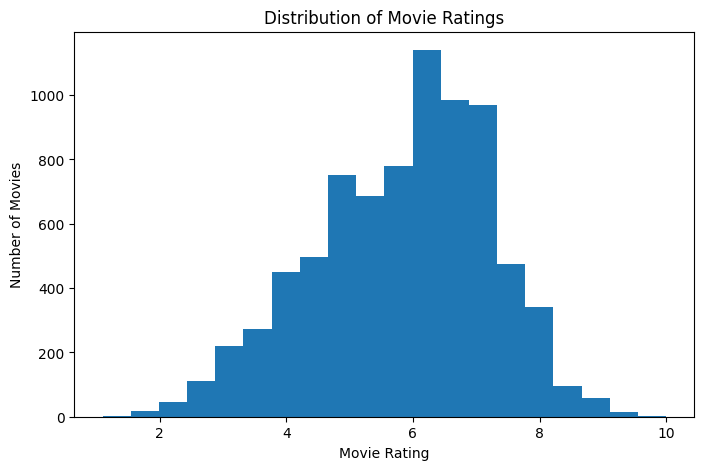

In [211]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df['Rating'], bins=20)

plt.xlabel("Movie Rating")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movie Ratings")

plt.show()

In [212]:
# Count movies by genre
genre_counts = df['Genre'].str.split(', ').explode().value_counts()

print("Top 10 Genres:")
print(genre_counts.head(10))

Top 10 Genres:
Genre
Drama        4924
Action       2358
Romance      1781
Comedy       1609
Crime        1111
Thriller      876
Family        663
Musical       498
Adventure     386
Mystery       370
Name: count, dtype: int64


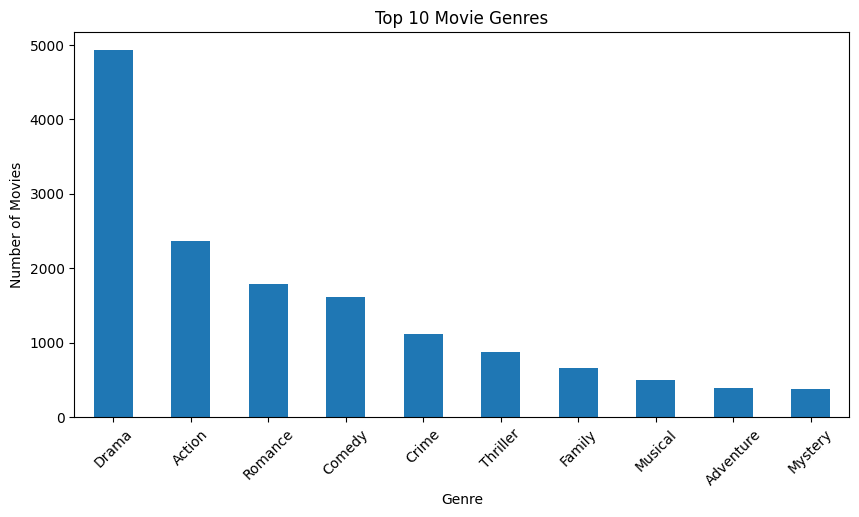

In [213]:
plt.figure(figsize=(10, 5))

genre_counts.head(10).plot(kind='bar')

plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.title("Top 10 Movie Genres")

plt.xticks(rotation=45)
plt.show()

In [214]:
# Select features and target
X = df[['Year', 'Duration', 'Votes']]
y = df['Rating']

print("Features:", X.columns.tolist())
print("Target: Rating")
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['Year', 'Duration', 'Votes']
Target: Rating
X shape: (7919, 3)
y shape: (7919,)


In [215]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (6335, 3)
Testing data: (1584, 3)


In [216]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [217]:
from sklearn.metrics import mean_absolute_error, r2_score

# Make predictions
y_pred = model.predict(X_test)

# Calculate performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1.048120146209968
R² Score: 0.07342153328958656


In [218]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

features = [
    'Year', 'Duration', 'Votes',
    'Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3'
]

X = df[features]
y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_features = ['Year', 'Duration', 'Votes']
categorical_features = ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

preprocessor = ColumnTransformer([
    ('num', 'passthrough', numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=5),
     categorical_features)
])

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest R² Score:", r2_rf)

Random Forest MAE: 0.8220406039562289
Random Forest R² Score: 0.35166671224118584


In [219]:
new_movie = pd.DataFrame({
    'Year': [2024],
    'Duration': [120],
    'Votes': [1000],
    'Genre': ['Drama'],
    'Director': ['Unknown'],
    'Actor 1': ['Unknown'],
    'Actor 2': ['Unknown'],
    'Actor 3': ['Unknown']
})

predicted_rating = rf_model.predict(new_movie)

print("Predicted Movie Rating:", round(predicted_rating[0], 2))

Predicted Movie Rating: 6.7
